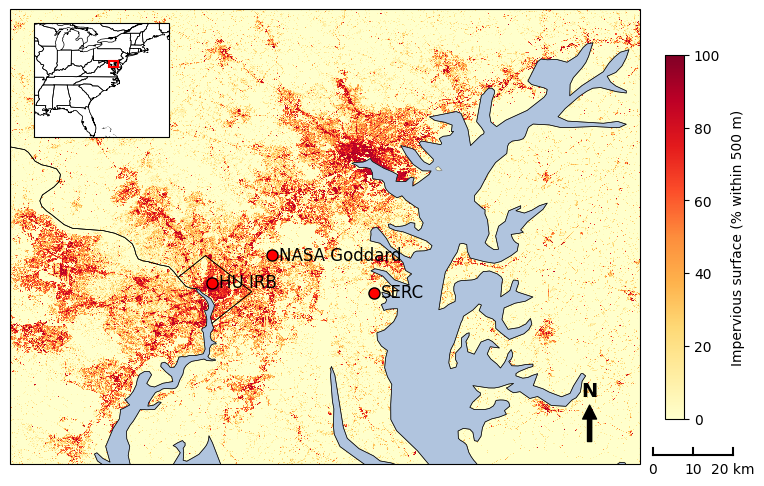

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np
import rioxarray

main_extent = [-77.6, -75.8, 38.4, 39.7]
inset_extent = [-92.0, -66.0, 25.0, 47.0]

sites = {
    "NASA Goddard": (38.9977, -76.8525),
    "HU IRB":       (38.9193, -77.0215),
    "SERC":         (38.890131, -76.560014),
}

fig = plt.figure(figsize=(9, 12))
ax = fig.add_axes([0.1, 0.1, 0.7, 0.8], projection=ccrs.PlateCarree())
ax.set_extent(main_extent, crs=ccrs.PlateCarree())

tif_path = "/Users/ujjawal/Downloads/Ceilometer Script/data/Annual_NLCD_FctImp_2024_CU_C1V1_73500eef-4690-4280-b48a-9188b6681a2a.tiff"
raster = rioxarray.open_rasterio(tif_path)
raster = raster.rio.reproject("EPSG:4326")

min_lon, max_lon, min_lat, max_lat = main_extent
raster_clipped = raster.rio.clip_box(minx=min_lon, miny=min_lat, maxx=max_lon, maxy=max_lat)

lons = raster_clipped.x.values
lats = raster_clipped.y.values
lon_grid, lat_grid = np.meshgrid(lons, lats)
z = raster_clipped.squeeze().values

z = np.where((z < 0) | (z > 100), np.nan, z)

im = ax.pcolormesh(lon_grid, lat_grid, z, transform=ccrs.PlateCarree(), 
                   cmap='YlOrRd', vmin=0, vmax=100, shading='auto')

water_color = '#B0C4DE' 
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', 
                                     facecolor=water_color, edgecolor='gray', linewidth=0.5)
lakes = cfeature.NaturalEarthFeature('physical', 'lakes', '10m', 
                                     facecolor=water_color, edgecolor='gray', linewidth=0.5)

ax.add_feature(ocean, zorder=2)
ax.add_feature(lakes, zorder=2)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.5, zorder=3, edgecolor='black', facecolor='none')

for site, (lat, lon) in sites.items():
    ax.plot(lon, lat, marker='o', color='green', markersize=8, 
            markeredgecolor='black', transform=ccrs.PlateCarree(), zorder=5)
    ax.text(lon + 0.02, lat, site, transform=ccrs.PlateCarree(),
            fontsize=12, ha='left', va='center',
            zorder=6)

inset_ax = ax.inset_axes([0.02, 0.72, 0.25, 0.25], projection=ccrs.PlateCarree())
inset_ax.set_extent(inset_extent, crs=ccrs.PlateCarree())

inset_ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
inset_ax.add_feature(cfeature.OCEAN, facecolor='white')
inset_ax.add_feature(cfeature.STATES, linewidth=0.5)

rect = mpatches.Rectangle((main_extent[0], main_extent[2]), 
                          main_extent[1] - main_extent[0], 
                          main_extent[3] - main_extent[2],
                          linewidth=1.5, edgecolor='red', facecolor='none',
                          transform=ccrs.PlateCarree(), zorder=10)
inset_ax.add_patch(rect)

cbar_ax = ax.inset_axes([1.04, 0.1, 0.03, 0.8])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label('Impervious surface (% within 500 m)', fontsize=10, labelpad=8)
cbar.set_ticks([0, 20, 40, 60, 80, 100])

ax.text(0.92, 0.15, 'N', transform=ax.transAxes, fontsize=14, fontweight='bold', ha='center')
ax.annotate('', xy=(0.92, 0.13), xytext=(0.92, 0.05), xycoords='axes fraction',
            arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=10),
            ha='center', va='center')

# Shifted scale bar to the right
bar_x_start = 1.02
bar_y = 0.02
bar_width = 0.128

ax.plot([bar_x_start, bar_x_start + bar_width], [bar_y, bar_y], 
        color='black', linewidth=1.5, transform=ax.transAxes, clip_on=False)

tick_x = [bar_x_start, bar_x_start + bar_width / 2, bar_x_start + bar_width]
labels = ['0', '10', '20 km']
for x, label in zip(tick_x, labels):
    ax.plot([x, x], [bar_y, bar_y + 0.015], color='black', linewidth=1.5, 
            transform=ax.transAxes, clip_on=False)
    ax.text(x, bar_y - 0.015, label, transform=ax.transAxes, 
            ha='center', va='top', fontsize=10)

plt.savefig('data/impervious_surface_map.png', dpi=300, bbox_inches='tight')
plt.show()